In [1]:
#libraries
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import librosa
import numpy as np
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report
from avex import load_model

c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-packages\google\api_core\_python_version_support.py:263: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)
c:\Users\anast\miniconda3\envs\bat-naturelm\lib\site-p

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score, 
    roc_curve, multilabel_confusion_matrix
)
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm

In [3]:
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F
import random
import math

In [4]:
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import os


In [5]:
import soundfile as sf

In [6]:
class BatAudioPipeline(torch.nn.Module):
    def __init__(self, target_sr=16000, expansion_factor=10, window_sec=10, overlap=0.5):
        super().__init__()
        self.target_sr = target_sr
        self.expansion_factor = expansion_factor
        
        # Windowing parameters
        self.win_samples = window_sec * target_sr
        self.hop_samples = int(self.win_samples * (1.0 - overlap))
        
        # BEATs usually uses 128 Mel bins
        self.mel_spectrogram = T.MelSpectrogram(
            sample_rate=target_sr,
            n_mels=128,
            n_fft=1024,
            hop_length=320 # 20ms frames
        )

    def load_and_expand(self, file_path):
        """Loads audio using soundfile to bypass TorchAudio DLL issues."""
        try:
            # Load using soundfile (returns numpy array and samplerate)
            data, orig_sr = sf.read(file_path)

            # Convert to torch tensor [channels, time]
            # soundfile returns [time, channels] for stereo, so we transpose
            audio = torch.from_numpy(data).float()
            if audio.ndim == 1:
                audio = audio.unsqueeze(0) # Add channel dim for mono
            else:
                audio = audio.transpose(0, 1) # [T, C] -> [C, T]

            # Convert stereo to mono if necessary
            if audio.shape[0] > 1:
                audio = torch.mean(audio, dim=0, keepdim=True)

            # 10x Time Expansion logic
            virtual_sr = orig_sr // self.expansion_factor

            # Resample to 16kHz for NatureLM
            if virtual_sr != self.target_sr:
                audio = F.resample(audio, orig_freq=virtual_sr, new_freq=self.target_sr)

            return audio

        except Exception as e:
            print(f"\n[Warning] Skipping {file_path}: {e}")
            # Return 1 second of silence as a fallback to prevent NoneType errors
            return torch.zeros((1, self.target_sr))

    def apply_bandpass(self, audio):
        """
        Filters frequencies Pipistrelles don't emit.
        In 10x expanded time, a 15kHz real-world high-pass becomes 1.5kHz.
        (The high-cut of 80kHz is already handled by the 16kHz resampling Nyquist limit).
        """
        # Highpass biquad filter at 1.5 kHz (Expanded domain)
        return F.highpass_biquad(audio, sample_rate=self.target_sr, cutoff_freq=1500.0)

    def generate_colored_noise(self, num_samples, exponent=1.0):
        """0.0=White, 1.0=Pink (Rain), 2.0=Brown (Roar)"""
        white_noise_fft = torch.fft.rfft(torch.randn(num_samples))
        frequencies = torch.fft.rfftfreq(num_samples)
        # Apply power law 1/f^beta
        scaler = 1.0 / (frequencies** (exponent / 2.0) + 1e-10)
        noise = torch.fft.irfft(white_noise_fft * scaler, n=num_samples)
        return (noise / (noise.std() + 1e-10)).unsqueeze(0)
    
    def add_noise_snr(self, audio, noise_audio, snr_db):
        """Mixes background noise at a specific Signal-to-Noise Ratio."""
        # Ensure noise is the same length as the audio
        if noise_audio.shape[1] < audio.shape[1]:
            # Repeat noise if it's too short
            repeats = math.ceil(audio.shape[1] / noise_audio.shape[1])
            noise_audio = noise_audio.repeat(1, repeats)
        
        # Trim noise to exact audio length
        noise_audio = noise_audio[:, :audio.shape[1]]
        
        # Calculate powers
        audio_power = audio.norm(p=2)
        noise_power = noise_audio.norm(p=2)
        
        # Avoid division by zero
        if noise_power == 0:
            return audio
            
        # Calculate required noise scalar to match target SNR
        # SNR = 20 * log10(audio_power / target_noise_power)
        target_noise_power = audio_power / (10 ** (snr_db / 20.0))
        noise_scalar = target_noise_power / noise_power
        
        # Mix
        mixed_audio = audio + (noise_audio * noise_scalar)
        return mixed_audio

    def random_gain(self, audio, min_db=-10, max_db=10):
        """Simulates different microphone sensitivities / distances."""
        gain_db = random.uniform(min_db, max_db)
        # Convert dB to linear scale multiplier
        multiplier = 10 ** (gain_db / 20.0)
        return audio * multiplier

    def window_audio(self, audio):
        """Cuts the 1D audio tensor into overlapping 10s windows."""
        # Unfold creates a view of the tensor in overlapping windows
        # Shape goes from [1, Total_Samples] -> [1, Num_Windows, Window_Samples]
        if audio.shape[1] < self.win_samples:
            # Pad with zeros if the file is shorter than 10 seconds
            pad_amount = self.win_samples - audio.shape[1]
            audio = torch.nn.functional.pad(audio, (0, pad_amount))
            
        windows = audio.unfold(-1, self.win_samples, self.hop_samples)
        # Rearrange to [Num_Windows, 1, Window_Samples] (Batch-like format)
        windows = windows.transpose(0, 1)
        return windows

    #def to_normalized_spectrogram(self, windows):
    #    """Converts raw audio windows to Log-Mel Spectrograms and normalizes."""
    #    # Output shape: [Num_Windows, 1, n_mels, time_frames]
    #    melspec = self.mel_spectrogram(windows)
    #    
    #    # Convert to log scale (adding small epsilon to prevent log(0))
    #    log_melspec = 10.0 * torch.log10(melspec + 1e-10)
    #    
    #    # Instance Normalization (Zero mean, unit variance per window)
    #    # Calculate mean and std over the frequency and time dimensions
    #    mean = log_melspec.mean(dim=[-2, -1], keepdim=True)
    #    std = log_melspec.std(dim=[-2, -1], keepdim=True)
    #    
    #    normalized_spec = (log_melspec - mean) / (std + 1e-8)
    #    
    #    return normalized_spec

    def to_raw_windows(self, windows):
        """NatureLM/BEATs expects raw waveform [Num_Windows, Time]."""
        # windows shape is [Num_Windows, 1, Samples]
        # We remove the channel dimension: [Num_Windows, Samples]
        windows = windows.squeeze(1)

        # Normalize: NatureLM usually expects zero-mean, unit variance raw audio
        #mean = windows.mean(dim=-1, keepdim=True)
        #std = windows.std(dim=-1, keepdim=True)
        #normalized_windows = (windows - mean) / (std + 1e-8)

        #return normalized_windows
        return windows


    def forward(self, file_path, noise_path=None, augment=False):
        """The complete sequence from file path to ML-ready tensor."""
        # 1. Load & Time Expand
        audio = self.load_and_expand(file_path)
        
        # 2. Bandpass Filter
        audio = self.apply_bandpass(audio)
        
        # 3. Data Augmentation (Only during Training)
        if augment:
            # Random Gain (-12dB to +6dB)
            audio = self.random_gain(audio, min_db=-12.0, max_db=6.0)
            
            # Mix Background Noise
            if random.random() > 0.3: # 70% chance to add noise
                snr = random.uniform(5.0, 25.0)
                # 1. Try to use your File-based noise (e.g., from ASA or Xeno-canto)
                if noise_path and os.path.exists(noise_path) and random.random() > 0.5:
                    try:
                        noise, n_sr = torchaudio.load(noise_path)
                        noise = F.resample(noise, n_sr, self.target_sr)
                        if noise.shape[0] > 1: noise = noise.mean(0, keepdim=True)
    
                        # Match length
                        if noise.shape[1] < audio.shape[1]:
                            noise = noise.repeat(1, (audio.shape[1] // noise.shape[1]) + 1)
                        noise = noise[:, :audio.shape[1]]
    
                        audio = self.add_noise_snr(audio, noise, snr)
                    except:
                        pass # Fallback to synthetic if file fails
                    
                # 2. Use Synthetic Colored Noise (Always available)
                else:
                    # Randomly pick a color: 0=Hiss, 1=Rain/Wind, 2=Deep Rumble
                    beta = random.uniform(0.0, 2.0)
                    noise = self.generate_colored_noise(audio.shape[1], exponent=beta)
                    audio = self.add_noise_snr(audio, noise.to(audio.device), snr)
        
        # 4. Cut into Windows
        windows = self.window_audio(audio)
        
        # 5. Convert to Normalized Spectrogram
        specs = self.to_raw_windows(windows)
        
        return specs

In [7]:
class PipistrelleDataset(Dataset):
    def __init__(self, csv_file, root_dir, noise_folder=None, is_training=True):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.is_training = is_training
        
        # Initialize our processing pipeline
        self.pipeline = BatAudioPipeline(target_sr=16000, expansion_factor=10)
        
        # Pre-load a list of noise files for augmentation
        self.noise_files = []
        if noise_folder and os.path.exists(noise_folder):
            self.noise_files = [os.path.join(noise_folder, f) for f in os.listdir(noise_folder) if f.endswith('.wav')]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        file_path = os.path.join(self.root_dir, row['relative_path'])
        
        # Grab a random noise file if we have them
        noise_path = random.choice(self.noise_files) if self.noise_files else None
        
        # Run the entire audio preprocessing and augmentation pipeline
        # Returns shape: [Num_Windows, 1, 128, Frames]
        windows_tensor = self.pipeline(file_path, noise_path=noise_path, augment=self.is_training)
        
        # Extract labels
        labels = torch.tensor([
            row['type_a'], row['type_b'], row['type_c'], 
            row['type_d'], row['echo']
        ], dtype=torch.float32)
        
        return windows_tensor, labels

# Example usage:
# dataset = PipistrelleDataset("bat_metadata.csv", "audio_data/", noise_folder="noise_data/", is_training=True)
# dataloader = DataLoader(dataset, batch_size=1, shuffle=True)
# for x, y in dataloader:
#     print(f"Input shape: {x.shape}, Labels: {y}")
#     break

In [9]:
test_ds = PipistrelleDataset("bat_metadata.csv", "C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\cnn-call-classifier\\BEATS Linear classifier\\xenocanto-dataset")
win, lab = test_ds[0]
print(f"Test Success! Shape: {win.shape}")

Test Success! Shape: torch.Size([104, 160000])


In [11]:
# --- 1. THE ATTENTION PROBE ---
class BatAttentionProbe(nn.Module):
    def __init__(self, encoder_dim=768, num_classes=5):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(encoder_dim, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
        self.classifier = nn.Linear(encoder_dim, num_classes)

    def forward(self, features):
        # If features are [Num_Windows, 1, 768], remove the middle dimension
        if features.dim() == 3:
            # Check if it's [Windows, Seq, Dim] - if so, mean pool over Seq
            if features.size(1) > 1:
                features = features.mean(dim=1)
            else:
                features = features.squeeze(1)

        # Now features is [Num_Windows, 768]

        # Calculate attention scores
        A = self.attention(features)             # [Num_Windows, 1]
        A = torch.softmax(A, dim=0)              # Softmax over windows
        A_T = torch.transpose(A, 1, 0)           # [1, Num_Windows]

        # matrix multiplication: [1, Num_Windows] @ [Num_Windows, 768] = [1, 768]
        bag_vector = torch.mm(A_T, features)     

        logits = self.classifier(bag_vector)     # [1, 5]
        return logits, A.squeeze()
    
# --- 2. EVALUATION PLOTTING ROUTINES ---
def plot_evaluation_results(all_targets, all_probs, class_names):
    all_targets = np.array(all_targets)
    all_probs = np.array(all_probs)
    all_preds = (all_probs >= 0.5).astype(int)

    # 1. Print Global Metrics
    print("\n" + "="*30)
    print("FINAL CROSS-VALIDATION METRICS")
    print("="*30)
    print(f"Global Subset Accuracy: {accuracy_score(all_targets, all_preds):.4f}")
    print(f"Macro F1-Score:       {f1_score(all_targets, all_preds, average='macro'):.4f}")
    print(f"Macro ROC-AUC:        {roc_auc_score(all_targets, all_probs, average='macro'):.4f}")
    
    # 2. Plot ROC Curves
    plt.figure(figsize=(10, 8))
    for i, class_name in enumerate(class_names):
        try:
            fpr, tpr, _ = roc_curve(all_targets[:, i], all_probs[:, i])
            auc = roc_auc_score(all_targets[:, i], all_probs[:, i])
            plt.plot(fpr, tpr, label=f"{class_name} (AUC = {auc:.3f})")
        except ValueError:
            pass # Handles edge cases where a fold might lack a specific class

    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
    plt.title("Receiver Operating Characteristic (ROC) per Class")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3. Plot Multi-label Confusion Matrices
    mcm = multilabel_confusion_matrix(all_targets, all_preds)
    fig, axes = plt.subplots(1, len(class_names), figsize=(4 * len(class_names), 4))
    
    for i, (ax, matrix, name) in enumerate(zip(axes, mcm, class_names)):
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['Neg', 'Pos'], yticklabels=['Neg', 'Pos'])
        ax.set_title(f"{name}")
        ax.set_xlabel("Predicted")
        if i == 0:
            ax.set_ylabel("Actual")
            
    plt.tight_layout()
    plt.suptitle("Class-wise Confusion Matrices (True Neg, False Pos | False Neg, True Pos)", y=1.05)
    plt.show()

# --- 3. THE TRAINING PIPELINE ---
def train_and_evaluate(dataset_csv, data_dir, noise_dir=None, num_epochs=10, folds=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")

    # 1. Load NatureLM Encoder (Frozen)
    print("Loading NatureLM Backbone...")
    encoder = load_model("esp_aves2_sl_beats_bio", device=device, return_features_only=True)
    encoder.eval() # Keep frozen
    
    # 2. Load Dataset
    # Assumes PipistrelleDataset from our previous steps is imported/defined
    full_dataset = PipistrelleDataset(dataset_csv, data_dir, noise_folder=noise_dir, is_training=True)
    class_names = ['Type_A', 'Type_B', 'Type_C', 'Type_D', 'Echo']
    
    # Calculate pos_weights for the 98/2 imbalance (optional but recommended)
    # This weights the social classes higher than the echo class in the loss function
    pos_weights = torch.tensor([10.0, 10.0, 10.0, 10.0, 1.0]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weights)

    # 3. K-Fold Cross Validation Setup
    kfold = KFold(n_splits=folds, shuffle=True, random_state=42)
    
    # Arrays to store global OOF (Out-Of-Fold) predictions for final evaluation
    global_targets = []
    global_probs = []

    for fold, (train_idx, val_idx) in enumerate(kfold.split(full_dataset)):
        print(f"\n--- Starting Fold {fold + 1}/{folds} ---")
        
        train_sub = Subset(full_dataset, train_idx)
        val_sub = Subset(full_dataset, val_idx)
        
        # Batch size 1 handles variable length bags easily
        train_loader = DataLoader(train_sub, batch_size=1, shuffle=True)
        val_loader = DataLoader(val_sub, batch_size=1, shuffle=False)
        
        # Initialize a fresh probe for this fold
        probe = BatAttentionProbe(encoder_dim=768, num_classes=5).to(device)
        optimizer = torch.optim.AdamW(probe.parameters(), lr=1e-4, weight_decay=1e-5)
        
        # --- TRAINING LOOP ---
        for epoch in range(num_epochs):
            probe.train()
            train_loss = 0.0
            
            for windows, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False):
                windows, labels = windows.to(device), labels.to(device) # windows: [1, Num_Win, 1, Mels, Time]
                
                # Squeeze out the batch dimension to pass the "bag" to the encoder
                windows = windows.squeeze(0) # [Num_Win, Samples]
                
                with torch.no_grad():
                    # Pass the bag through the frozen NatureLM encoder
                    # Extract the CLS token or average pooling depending on NatureLM spec
                    feats = encoder(windows) 
                    # Assuming NatureLM returns [Num_Win, 768] directly or last_hidden_state
                    if hasattr(feats, 'last_hidden_state'):
                        feats = feats.last_hidden_state.mean(dim=1) 
                    elif isinstance(feats, dict):
                         feats = feats['x'] # Adjust based on specific avex return dict
                
                # Pass features to Attention Probe
                optimizer.zero_grad()
                logits, attention_weights = probe(feats)
                
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()
                
                train_loss += loss.item()
                
        # --- VALIDATION LOOP (Out-Of-Fold) ---
        probe.eval()
        fold_targets, fold_probs = [], []
        
        with torch.no_grad():
            for windows, labels in val_loader:
                windows, labels = windows.to(device), labels.to(device)
                windows = windows.squeeze(0)
                
                feats = encoder(windows)
                if hasattr(feats, 'last_hidden_state'):
                    feats = feats.last_hidden_state.mean(dim=1)
                elif isinstance(feats, dict):
                    feats = feats['x']
                    
                logits, _ = probe(feats)
                probs = torch.sigmoid(logits).cpu().numpy()[0]
                
                fold_targets.append(labels.cpu().numpy()[0])
                fold_probs.append(probs)
                
        # Save OOF predictions for global metrics
        global_targets.extend(fold_targets)
        global_probs.extend(fold_probs)
        
        # Quick fold metric print
        fold_auc = roc_auc_score(np.array(fold_targets), np.array(fold_probs), average='macro')
        print(f"Fold {fold + 1} Macro AUC: {fold_auc:.4f}")

    # 4. Final Global Evaluation
    plot_evaluation_results(global_targets, global_probs, class_names)

In [18]:
# --- EXECUTION ---
if __name__ == "__main__":
    # Replace with your actual paths
    CSV_PATH = "bat_metadata.csv"
    AUDIO_DIR =  "C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\cnn-call-classifier\\BEATS Linear classifier\\xenocanto-dataset"
    NOISE_DIR = None # Or None if using pure synthetic
    
train_and_evaluate(CSV_PATH, AUDIO_DIR, NOISE_DIR, num_epochs=15, folds=5)

Using device: cpu
Loading NatureLM Backbone...

--- Starting Fold 1/5 ---


KeyboardInterrupt: 

In [8]:
def build_feature_bank(dataset, encoder, device='cpu'):
    feature_list = []
    label_list = []
    
    encoder.eval()
    with torch.no_grad():
        for i in tqdm(range(len(dataset)), desc="Extracting Features"):
            windows, labels = dataset[i]
            # windows shape: [Num_Windows, 160000]
            
            # Pass through NatureLM
            feats = encoder(windows.to(device))
            if isinstance(feats, dict): feats = feats['x']
            
            # Global Average Pooling: Turn the "Bag" into one 768-dim vector
            # This is the "average fingerprint" of the whole recording
            bag_feature = feats.mean(dim=0).cpu().numpy() 
            
            feature_list.append(bag_feature)
            label_list.append(labels.numpy())
            
    return np.array(feature_list), np.array(label_list)

CSV_PATH = "bat_metadata.csv"
AUDIO_DIR =  "C:\\Users\\anast\\Desktop\\College\\BA6\\Bachelor Project\\Source Code\\cnn-call-classifier\\BEATS Linear classifier\\xenocanto-dataset"
NOISE_DIR = None # Or None if using pure synthetic
full_dataset = PipistrelleDataset(CSV_PATH, AUDIO_DIR, noise_folder=NOISE_DIR, is_training=False)
encoder = load_model("esp_aves2_naturelm_audio_v1_beats", device='cpu', return_features_only=True)
# X: [N, 768], Y: [N, 5]
X, Y = build_feature_bank(full_dataset, encoder)
np.save("X_features_NLM.npy", X)
np.save("Y_labels_NLM.npy", Y)


Extracting Features: 100%|██████████| 284/284 [2:59:54<00:00, 38.01s/it]  


In [9]:
# Load the files you saved
X_new = np.load("X_features.npy")
Y_new = np.load("Y_labels.npy")

print(f"Features Loaded: {X_new.shape}") # Should show [Total_Files, 768]
print(f"Labels Loaded:   {Y_new.shape}") # Should show [Total_Files, 5]

# A quick 'sanity check' - check the first row
print("\nFirst feature vector (first 5 values):", X_new[0][:5])
print("First label row:", Y_new[0])

Features Loaded: (284, 496, 768)
Labels Loaded:   (284, 5)

First feature vector (first 5 values): [[-0.08391559 -0.15062939  0.07014083 ... -0.012716   -0.13664396
  -0.284124  ]
 [ 0.31610987 -0.1517662  -0.04822176 ...  0.32519463 -0.43320924
  -0.30183473]
 [ 0.34330317 -0.25278264  0.11272869 ...  0.68754476 -0.40508208
  -0.32374784]
 [ 0.6048931  -0.38526133  0.16893122 ...  0.7137939  -0.6423224
  -0.33048674]
 [ 0.6841529  -0.23642777  0.2587288  ...  0.5682522  -0.6518665
  -0.26245183]]
First label row: [0. 0. 0. 0. 1.]


In [9]:
def create_composition_labels(y_matrix, label_names):
    comp_labels = []
    for row in y_matrix:
        active = [label_names[i] for i, val in enumerate(row) if val == 1]
        if not active:
            comp_labels.append("Silence/Other")
        else:
            comp_labels.append(" + ".join(active))
    return comp_labels

In [10]:
import matplotlib.colors as mcolors

# 1. Define distinct base colors for your 5 categories
base_colors = {
    'Type A': '#1f77b4', # Blue
    'Type B': '#ff7f0e', # Orange
    'Type C': '#2ca02c', # Green
    'Type D': '#d62728', # Red
    'Echo':   '#9467bd'  # Purple
}

def mix_multi_labels(row, label_names, base_colors):
    """
    Finds all active labels in a row and averages their RGB colors.
    """
    active_indices = [i for i, val in enumerate(row) if val == 1]
    
    if not active_indices:
        return mcolors.to_rgb('#e0e0e0') # Light grey for unlabeled/silence
    
    # Get RGB tuples for all active labels
    rgbs = [mcolors.to_rgb(base_colors[label_names[i]]) for i in active_indices]
    
    # Average the RGB values
    mixed_rgb = np.mean(rgbs, axis=0)
    return mixed_rgb

Found 16 unique label combinations in your data:
 - Echo
 - Type A
 - Type B
 - Type C
 - Type D
 - Type A + Type B
 - Type A + Type C
 - Type B + Echo
 - Type B + Type C
 - Type C + Echo
 - Type D + Echo
 - Type A + Type B + Echo
 - Type A + Type B + Type C
 - Type A + Type C + Echo
 - Type B + Type C + Echo
 - Type C + Type D + Echo


<Figure size 1000x640 with 0 Axes>

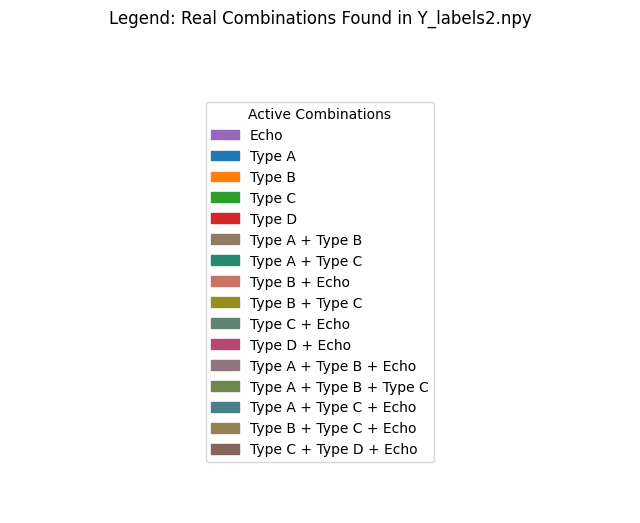

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Define your base colors
base_colors = {
    'Type A': '#1f77b4', # Blue
    'Type B': '#ff7f0e', # Orange
    'Type C': '#2ca02c', # Green
    'Type D': '#d62728', # Red
    'Echo':   '#9467bd'  # Purple
}

# 2. Load your actual data
y = np.load("Y_labels.npy")
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

def hex_to_rgb(hex_str):
    hex_str = hex_str.lstrip('#')
    return np.array([int(hex_str[i:i+2], 16) for i in (0, 2, 4)])

def rgb_to_hex(rgb):
    return "#{:02x}{:02x}{:02x}".format(int(rgb[0]), int(rgb[1]), int(rgb[2]))

# 3. Identify unique combinations present in the data
found_combos = []
for row in y:
    # Identify which labels are active (value == 1)
    active = [label_names[i] for i, val in enumerate(row) if val == 1]
    
    # User constraint: Max 3 labels
    if len(active) > 3:
        active = active[:3]
    
    if active:
        found_combos.append(tuple(active))

# Get unique combinations and sort them (Singles first, then Pairs, then Triplets)
unique_combos = sorted(list(set(found_combos)), key=lambda x: (len(x), x))

# 4. Generate colors and legend handles ONLY for existing combinations
plt.figure(figsize=(10, len(unique_combos) * 0.4))
legend_handles = []

print(f"Found {len(unique_combos)} unique label combinations in your data:")

for combo in unique_combos:
    if len(combo) == 1:
        color = base_colors[combo[0]]
    else:
        # Blend colors
        rgbs = [hex_to_rgb(base_colors[label]) for label in combo]
        color = rgb_to_hex(np.mean(rgbs, axis=0))
    
    label_text = " + ".join(combo)
    print(f" - {label_text}")
    
    patch = mpatches.Patch(color=color, label=label_text)
    legend_handles.append(patch)

# 5. Plot the legend
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_axis_off()
ax.legend(handles=legend_handles, loc='center', ncol=1, title="Active Combinations", fontsize=10)
plt.title("Legend: Real Combinations Found in Y_labels2.npy", pad=20)
plt.show()

Running PCA...
Running UMAP...
Running t-SNE...


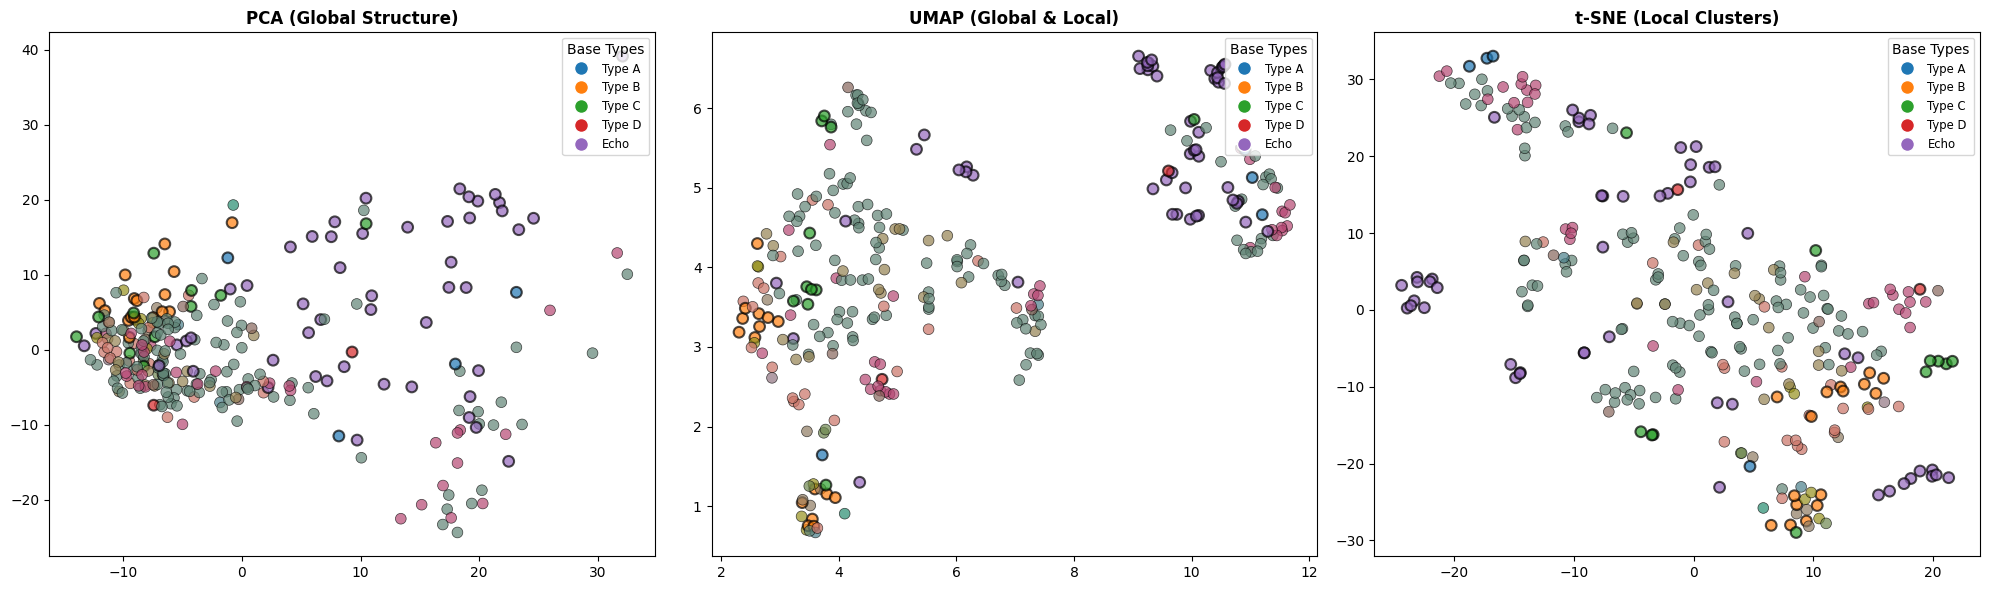

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from matplotlib.lines import Line2D
import umap

# 1. Load Data
X = np.load("X_features_NLM.npy")
y = np.load("Y_labels_NLM.npy")

# --- Label Prep ---
# Create a single 'Class' label for coloring. 
# We'll pick the first active 'Type' column, or 'None' if all 0.
#label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
#def get_primary_label(row):
#    for i, val in enumerate(row):
#        if val == 1: return label_names[i]
#    return 'Other/Silence'
#
#color_labels = [get_primary_label(row) for row in y]

# Usage
label_names = ['A', 'B', 'C', 'D', 'Echo']
color_labels = create_composition_labels(y, label_names)
# Generate the color array for your data
label_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']
point_colors = [mix_multi_labels(row, label_names, base_colors) for row in y]

# Now use 'color_labels' in the sns.scatterplot(hue=color_labels) 
# code from the previous step.

# 2. Preprocessing (Standard Scaling is CRITICAL)
#  Average the windows and Scale the data
X_2d = np.max(X, axis=(1)) if X.ndim == 3 else X
X_scaled = StandardScaler().fit_transform(X_2d)


# 3. Apply Dimensionality Reduction
print("Running PCA...")
pca_res = PCA(n_components=2).fit_transform(X_scaled)

print("Running UMAP...")
umap_res = umap.UMAP(n_neighbors=40, min_dist=0.1, metric='cosine').fit_transform(X_scaled)

print("Running t-SNE...")
tsne_res = TSNE(n_components=2, perplexity=25, init='pca', learning_rate='auto').fit_transform(X_scaled)

# 4. Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
titles = ['PCA (Global Structure)', 'UMAP (Global & Local)', 't-SNE (Local Clusters)']
results = [pca_res, umap_res, tsne_res]

for i, res in enumerate(results):
    ax = axes[i]
    
    
    edge_widths = [1.5 if row.sum() == 1 else 0.5 for row in y]
    
    # Use ax.scatter instead of sns.scatterplot
    # This allows us to pass our mixed 'point_colors' directly to 'c'
    ax.scatter(
        res[:, 0], res[:, 1], 
        c=point_colors, 
        s=60, alpha=0.7, 
        edgecolor='black', 
        linewidth=edge_widths
    )
    
    ax.set_title(titles[i], fontweight='bold')
    
    # Since we aren't using Seaborn's auto-legend, we add a manual one
    # using the base_colors dictionary we defined earlier
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label=k,
               markerfacecolor=v, markersize=10) 
        for k, v in base_colors.items()
    ]
    ax.legend(handles=legend_elements, title="Base Types", loc='upper right', fontsize='small')

plt.tight_layout()
plt.show()

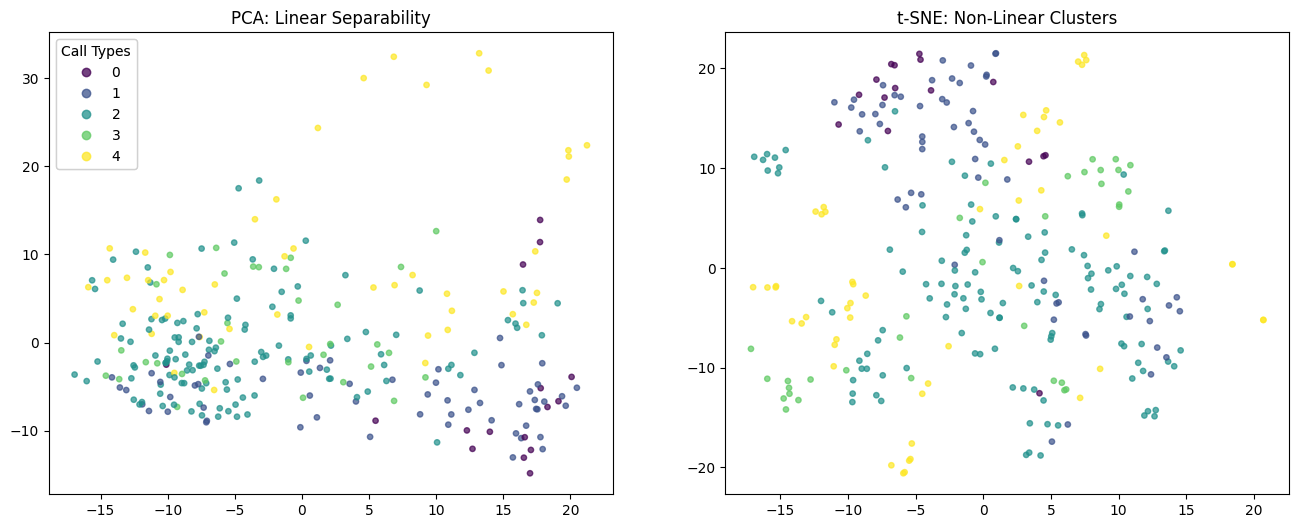

In [ ]:
#PCA and t-SNE Visualization

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Pre-processing: Average the windows and Scale the data
X_2d = np.max(X, axis=1) if X.ndim == 3 else X
#X_2d = np.mean(X, axis=1) if X.ndim == 3 else X
X_scaled = StandardScaler().fit_transform(X_2d)

# 2. Run PCA (Fast)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. Run t-SNE (Slower, but better for 'blobs')
# Note: if your CPU is struggling, set n_iter=300
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

# 4. Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# We use argmax to pick the 'main' class for the color of the dot
colors = np.argmax(Y, axis=1)
class_names = ['Type A', 'Type B', 'Type C', 'Type D', 'Echo']

scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap='viridis', s=15, alpha=0.7)
ax1.set_title("PCA: Linear Separability")

scatter2 = ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, cmap='viridis', s=15, alpha=0.7)
ax2.set_title("t-SNE: Non-Linear Clusters")

# Add a legend
legend1 = ax1.legend(*scatter1.legend_elements(), title="Call Types")
ax1.add_artist(legend1)

plt.show()


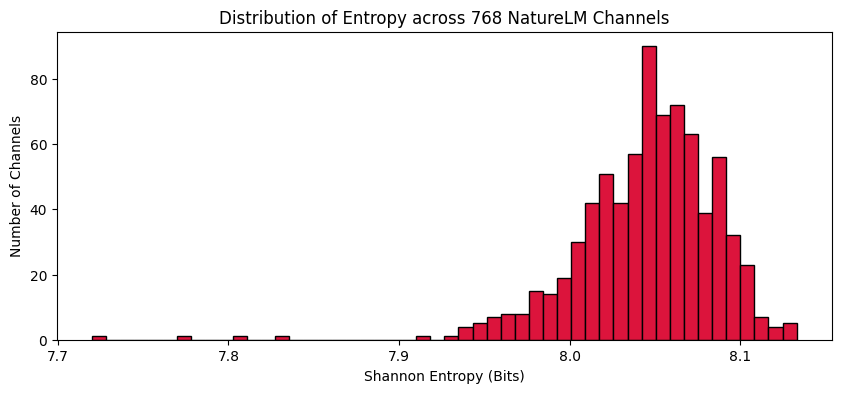

Mean Channel Entropy: 8.05
Most 'Informative' Channel Index: 756


In [ ]:
#Channel-wise Entropy Calculation

def get_channel_entropy(X_2d):
    # Ensure all values are positive for probability calculation
    # We shift the distribution so the minimum is 0
    X_pos = X_2d - np.min(X_2d, axis=0)
    
    # Turn each channel into a probability distribution across samples
    # (Sum of activations across all files for that channel = 1.0)
    probs = X_pos / (np.sum(X_pos, axis=0) + 1e-12)
    
    # Calculate Shannon Entropy per channel
    entropy = -np.sum(probs * np.log2(probs + 1e-12), axis=0)
    return entropy

# Calculate
entropies = get_channel_entropy(X_2d)

# Visualize the distribution of "information"
plt.figure(figsize=(10, 4))
plt.hist(entropies, bins=50, color='crimson', edgecolor='black')
plt.title("Distribution of Entropy across 768 NatureLM Channels")
plt.xlabel("Shannon Entropy (Bits)")
plt.ylabel("Number of Channels")
plt.show()

print(f"Mean Channel Entropy: {np.mean(entropies):.2f}")
print(f"Most 'Informative' Channel Index: {np.argmin(entropies)}")

Manifold Separability Score (Silhouette): -0.0856


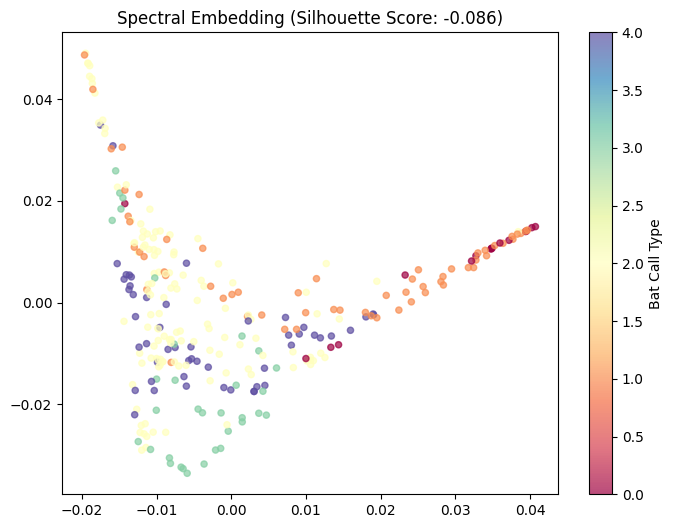

In [ ]:
#Spectral embedding

from sklearn.manifold import SpectralEmbedding
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare features (Max Pooling is still our winner)
X_max = np.max(X, axis=1) if X.ndim == 3 else X
X_scaled = StandardScaler().fit_transform(X_max)

# 2. Run Spectral Embedding (The 'Library-Free' UMAP)
# n_neighbors: How many neighbors to look at (similar to UMAP's n_neighbors)
se = SpectralEmbedding(n_components=2, n_neighbors=15, affinity='nearest_neighbors', random_state=42)
X_se = se.fit_transform(X_scaled)

# 3. 'Measurement': Silhouette Score
# This tells us how well-separated the clusters actually are (-1 to 1)
colors = np.argmax(Y, axis=1)
score = silhouette_score(X_se, colors)
print(f"Manifold Separability Score (Silhouette): {score:.4f}")

# 4. Plotting
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_se[:, 0], X_se[:, 1], c=colors, cmap='Spectral', s=20, alpha=0.7)
plt.title(f"Spectral Embedding (Silhouette Score: {score:.3f})")
plt.colorbar(scatter, label='Bat Call Type')
plt.show()

In [ ]:
#Random Forest Baseline (Using the Max-Pooled features)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# Using your Max-Pooled features (the ones that looked better)
# X_max shape: [Samples, 768]
# y shape: [Samples,] (the main class)
y_single = np.argmax(Y, axis=1)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
scores = cross_val_score(clf, X_max, y_single, cv=5)

print(f"Random Forest Baseline Accuracy: {scores.mean():.2%}")

Random Forest Baseline Accuracy: 54.94%


In [29]:
#SVM Baseline
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# 1. Use the version of the data that showed the most promise
X_max = np.max(X, axis=1) if X.ndim == 3 else X
y_single = np.argmax(Y, axis=1)

# 2. Linear SVM with 'C' parameter 
# (A smaller C like 0.1 makes the model even more robust to noise)
clf = make_pipeline(StandardScaler(), LinearSVC(C=0.1, random_state=42, max_iter=2000))

# 3. Honest Cross-Validation
scores = cross_val_score(clf, X_max, y_single, cv=5)

print(f"SVM Honest Accuracy: {scores.mean():.2%}")

SVM Honest Accuracy: 64.47%


In [28]:
#Attntion probe on extracted features

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINE THE MODEL
class RobustAttentionMIL(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=64, num_classes=5): # Smaller hidden_dim
        super(RobustAttentionMIL, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(0.3), # ADD DROPOUT
            nn.Linear(hidden_dim, 1)
        )
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), # ADD DROPOUT
            nn.Linear(input_dim, num_classes)
        )

    def forward(self, x):
        b, n, d = x.shape
        x_flat = x.reshape(-1, d)
        attn_scores = self.attention(x_flat).view(b, n, 1)
        weights = torch.softmax(attn_scores, dim=1)
        
        # Weighted sum
        bag_vector = torch.sum(x * weights, dim=1)
        logits = self.classifier(bag_vector)
        return logits, weights

# 2. PREPARE DATA
X_3d = np.load("X_features.npy") # [Samples, 11, 768]
Y_labels = np.load("Y_labels.npy") # [Samples, 5]

X_tensor = torch.tensor(X_3d, dtype=torch.float32)
Y_tensor = torch.tensor(Y_labels, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tensor, Y_tensor), batch_size=16, shuffle=True)

# 3. SETUP TRAINING
device = torch.device("cpu")
criterion = nn.BCEWithLogitsLoss()

from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

print("Running Honest 5-Fold Cross-Validation...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_tensor)):
    # Split the tensors
    train_x, val_x = X_tensor[train_idx], X_tensor[val_idx]
    train_y, val_y = Y_tensor[train_idx], Y_tensor[val_idx]
    
    # Reset model for each fold
    fold_model = RobustAttentionMIL().to(device)
    optimizer = optim.Adam(fold_model.parameters(), lr=0.0005, weight_decay=1e-3)
    
    # Train for 40 epochs per fold
    for epoch in range(40):
        fold_model.train()
        logits, _ = fold_model(train_x)
        loss = criterion(logits, train_y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    # Evaluate on "Unseen" data
    fold_model.eval()
    with torch.no_grad():
        val_logits, _ = fold_model(val_x)
        preds = (torch.sigmoid(val_logits) > 0.5).float()
        acc = (preds == val_y).all(dim=1).float().mean()
        fold_accuracies.append(acc.item())
        print(f"Fold {fold+1} Accuracy: {acc.item():.2%}")

print(f"\n📢 REAL WORLD ACCURACY: {np.mean(fold_accuracies):.2%}")

Running Honest 5-Fold Cross-Validation...
Fold 1 Accuracy: 43.86%
Fold 2 Accuracy: 54.39%
Fold 3 Accuracy: 54.39%
Fold 4 Accuracy: 57.89%
Fold 5 Accuracy: 53.57%

📢 REAL WORLD ACCURACY: 52.82%


In [98]:
# 0. Load your metadata
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC # Use SVC instead of LinearSVC for RBF

df_meta = pd.read_csv("final_metadata_len.csv")

# 1. Load your 3D Data
X_3d = np.load("X_features.npy") # Shape: (284, 496, 768)
Y_labels = np.load("Y_labels.npy") # Shape: (284, 5)

# 2. POOLING: Convert 3D to 2D (Fixes your error)
# We take the Maximum value across the 496 windows for each of the 768 features.
print("Pooling 3D features into 2D via Max-Pooling...")
X_2d = np.max(X_3d, axis=1) # New Shape: (284, 768)
#X_sorted = np.sort(X_3d, axis=1)
#X_2d = np.mean(X_sorted[:, -10:, :], axis=1) # Average of the 10 strongest windows

# 3. Create weights from CSV
# If duration <= 15 seconds, it's a "Gold" recording (5x weight)
weights = df_meta['duration'].apply(lambda d: 5.0 if d <= 15 else 1.0).values
#weights = np.ones(len(df_meta)) 
# 4. Weighted Training Loop
y_single = np.argmax(Y_labels, axis=1)
scaler = StandardScaler()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

final_scores = []
X_scaled = scaler.fit_transform(X_2d)

print(f"Starting SVM on {X_scaled.shape} data...")

for train_idx, val_idx in skf.split(X_scaled, y_single):
    # Split
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_single[train_idx], y_single[val_idx]
    w_train = weights[train_idx]
    
    selector = SelectKBest(f_classif, k=768) # Keep only the 200 best features
    X_train_selected = selector.fit_transform(X_train, y_train)
    X_val_selected = selector.transform(X_val)

    #linear SVM
    #77.8% accuracy with 500 features
    #78.87% with 575 features
    #79.2% with 297 features (best so far)

    #81.34 with RBF kernel and all features

    #clf = LinearSVC(C=0.1, class_weight='balanced', random_state=42, max_iter=10000)
    clf = SVC(
    kernel='rbf', 
    C=1.0,           # Standard starting point
    gamma='scale',   # Auto-adjusts to feature spread
    class_weight='balanced',
    random_state=42
)
    clf.fit(X_train_selected, y_train, sample_weight=w_train)
    score = clf.score(X_val_selected, y_val)

    # Fit Weighted SVM
    #clf.fit(X_train, y_train, sample_weight=w_train)
    
    final_scores.append(clf.score(X_val_selected, y_val))

print(f"\n🚀 Final Metadata-Weighted SVM Accuracy: {np.mean(final_scores):.2%}")

Pooling 3D features into 2D via Max-Pooling...
Starting SVM on (284, 768) data...

🚀 Final Metadata-Weighted SVM Accuracy: 81.34%


In [ ]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold

# 1. Load the Data
# allow_pickle=True is a safety net in case numpy saved differing lengths as an 'object' array
X_3d = np.load("X_features.npy", allow_pickle=True)
Y_labels = np.load("Y_labels.npy")

# --- THE DURATION LOGIC ---
print("Calculating file durations based on active windows...")
durations = []

# Scenario A: The array is a perfect 3D cube [Files, Windows, 768] (Zero-padded)
if X_3d.ndim == 3:
    for i in range(len(X_3d)):
        # Calculate the total magnitude of each window
        window_magnitudes = np.sum(np.abs(X_3d[i]), axis=1)
        
        # If the magnitude is greater than a tiny number, it's a real audio window (not padding)
        active_windows = np.sum(window_magnitudes > 1e-6)
        durations.append(active_windows)
        
# Scenario B: The array is a list of different-sized arrays
else:
    for i in range(len(X_3d)):
        durations.append(len(X_3d[i]))

durations = np.array(durations)
print(f"Stats - Shortest file: {np.min(durations)} windows | Longest: {np.max(durations)} windows")

# --- THE WEIGHTING LOGIC ---
weights = np.ones(len(durations))

# Define what a "Short/Pure" file is based on the windows.
# If 1 window = ~5 seconds, then files with <= 3 windows are under 15 seconds.
short_threshold = 3 

# Give 5x importance to the short, pure recordings
weights[durations <= short_threshold] = 5.0
weights[durations > short_threshold] = 1.0

pure_count = np.sum(durations <= short_threshold)
print(f"Assigned high weight (5x) to {pure_count} 'pure' short recordings.")
print(f"Assigned normal weight (1x) to {len(durations) - pure_count} long recordings.")

# 2. Pre-process into 2D Max-Pooled Features
if X_3d.ndim == 3:
    X_max = np.max(X_3d, axis=1)
else:
    # Safely max-pool if the lengths are all different
    X_max = np.array([np.max(x, axis=0) for x in X_3d])

y_single = np.argmax(Y_labels, axis=1)

# 3. The Weighted SVM Training Loop
# C=0.1 keeps the model simple to prevent overfitting on the small dataset
clf = LinearSVC(
    C=0.1, 
    random_state=42, 
    max_iter=5000, 
    class_weight={0: 10.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0} # 10x weight for Class 0
)
scaler = StandardScaler()
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []
X_scaled = scaler.fit_transform(X_max)

print("\nRunning Honest 5-Fold Cross-Validation with Sample Weights...")
for fold, (train_idx, val_idx) in enumerate(skf.split(X_scaled, y_single)):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_single[train_idx], y_single[val_idx]
    w_train = weights[train_idx]
    
    # Train the SVM WITH the weights
    clf.fit(X_train, y_train, sample_weight=w_train)
    
    # Evaluate WITHOUT weights (to get a true real-world accuracy score)
    fold_score = clf.score(X_val, y_val)
    scores.append(fold_score)
    print(f"Fold {fold+1} Accuracy: {fold_score:.2%}")

print(f"\n🚀 Final Weighted SVM Accuracy: {np.mean(scores):.2%}")

Calculating file durations based on active windows...
Stats - Shortest file: 496 windows | Longest: 496 windows
Assigned high weight (5x) to 0 'pure' short recordings.
Assigned normal weight (1x) to 284 long recordings.

Running Honest 5-Fold Cross-Validation with Sample Weights...
Fold 1 Accuracy: 71.93%
Fold 2 Accuracy: 78.95%
Fold 3 Accuracy: 82.46%
Fold 4 Accuracy: 77.19%
Fold 5 Accuracy: 75.00%

🚀 Final Weighted SVM Accuracy: 77.11%


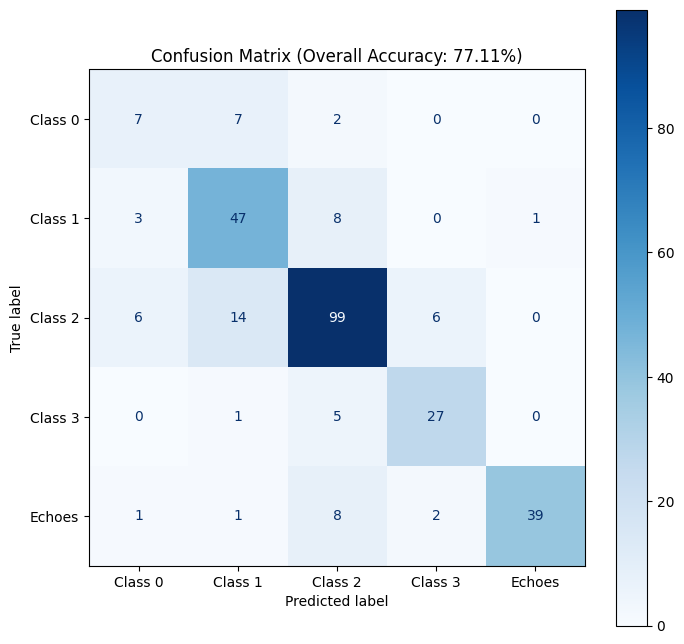

Class 0 Recall: 43.75%
Class 1 Recall: 79.66%
Class 2 Recall: 79.20%
Class 3 Recall: 81.82%
Echoes Recall: 76.47%


In [ ]:
#Conusion Matrix for the Weighted SVM

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# We'll collect all real labels and all predictions from the CV loop
all_y_true = []
all_y_pred = []

# Re-running the loop briefly to collect predictions
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, val_idx in skf.split(X_scaled, y_single):
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_train, y_val = y_single[train_idx], y_single[val_idx]
    w_train = weights[train_idx]
    
    clf.fit(X_train, y_train, sample_weight=w_train)
    preds = clf.predict(X_val)
    
    all_y_true.extend(y_val)
    all_y_pred.extend(preds)

# --- Plotting the Results ---
fig, ax = plt.subplots(figsize=(8, 8))

# Replace these names with your actual bat species names if you have them!
target_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Echoes']

cm = confusion_matrix(all_y_true, all_y_pred)
# Normalize to show percentages (easier to read)
cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title(f"Confusion Matrix (Overall Accuracy: {np.mean(scores):.2%})")
plt.show()

# Print a quick summary of the "Troublemakers"
for i, name in enumerate(target_names):
    accuracy = cm_perc[i, i]
    print(f"{name} Recall: {accuracy:.2%}")

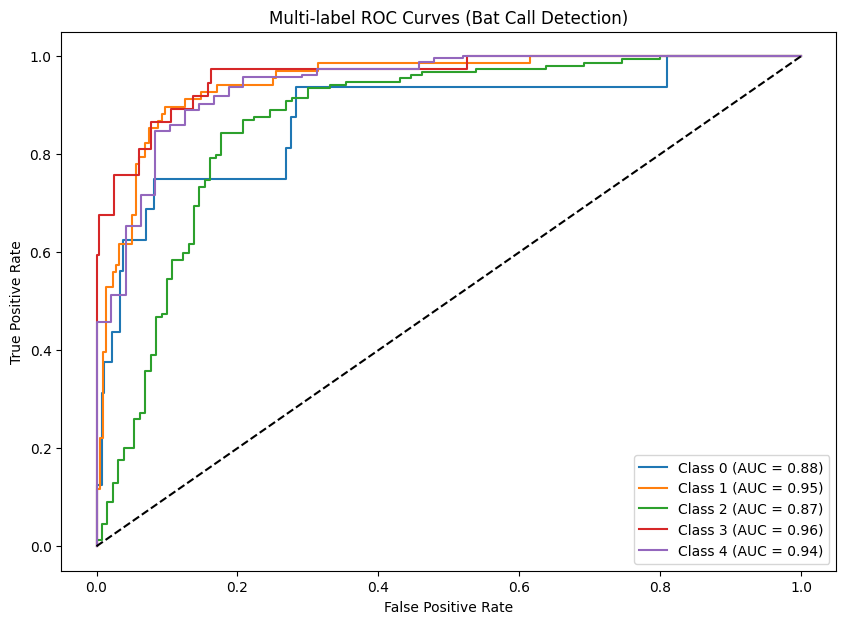

In [36]:
#ROC curves
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# 1. Setup One-Vs-Rest with SVM
# We use the decision_function to get "scores" instead of binary 0/1
clf_ovr = OneVsRestClassifier(LinearSVC(C=0.1, random_state=42, class_weight='balanced'))

# 2. Collect scores across folds
all_y_true = []
all_y_scores = []

for train_idx, val_idx in skf.split(X_scaled, y_single):
    # Note: Even if we use y_single for splitting, we use the 
    # multi-label Y_labels for actual training/testing
    X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
    Y_train, Y_val = Y_labels[train_idx], Y_labels[val_idx]
    
    clf_ovr.fit(X_train, Y_train)
    scores = clf_ovr.decision_function(X_val)
    
    all_y_true.append(Y_val)
    all_y_scores.append(scores)

all_y_true = np.vstack(all_y_true)
all_y_scores = np.vstack(all_y_scores)

# 3. Plot ROC for each class
plt.figure(figsize=(10, 7))
for i in range(5):
    fpr, tpr, _ = roc_curve(all_y_true[:, i], all_y_scores[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-label ROC Curves (Bat Call Detection)')
plt.legend(loc='lower right')
plt.show()

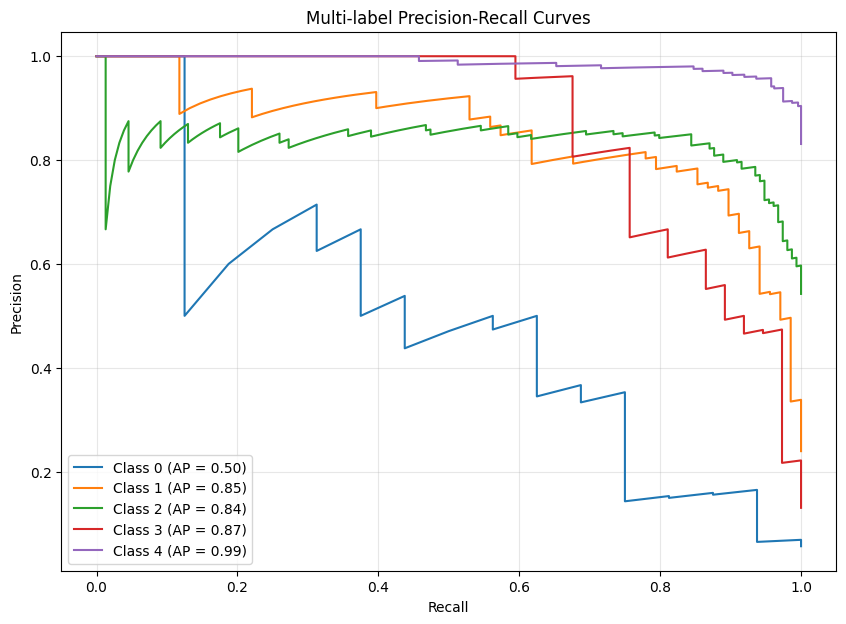

In [37]:
#Precision recall curve

from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10, 7))

for i in range(5):
    precision, recall, thresholds = precision_recall_curve(all_y_true[:, i], all_y_scores[:, i])
    avg_precision = average_precision_score(all_y_true[:, i], all_y_scores[:, i])
    plt.plot(recall, precision, label=f'Class {i} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Multi-label Precision-Recall Curves')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

In [38]:
#Attention MIL with weights for shorter recordings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import KFold
import numpy as np

# 1. The Attention Model
class AttentionMIL(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=128, num_classes=5):
        super(AttentionMIL, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Tanh(),
            nn.Dropout(0.2), # A little dropout to prevent memorizing
            nn.Linear(hidden_dim, 1)
        )
        self.classifier = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        b, n, d = x.shape
        x_flat = x.reshape(-1, d)
        
        attn_scores = self.attention(x_flat).view(b, n, 1)
        weights = torch.softmax(attn_scores, dim=1)
        
        # Weighted sum of the windows
        bag_vector = torch.sum(x * weights, dim=1)
        logits = self.classifier(bag_vector)
        return logits, weights

# 2. Prepare Data and Weights
# (Assuming X_3d, Y_labels, and the 'weights' array from the SVM step are still in memory)
X_tensor = torch.tensor(X_3d, dtype=torch.float32)
Y_tensor = torch.tensor(Y_labels, dtype=torch.float32)

# Reshape weights to match PyTorch broadcasting [Batch_Size, 1]
W_tensor = torch.tensor(weights, dtype=torch.float32).unsqueeze(1) 

# 3. Setup Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []
device = torch.device("cpu")

print("Running Weighted Attention Probe (Honest 5-Fold CV)...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_tensor)):
    
    # Split the tensors (Notice we include W_tensor now!)
    train_x, val_x = X_tensor[train_idx], X_tensor[val_idx]
    train_y, val_y = Y_tensor[train_idx], Y_tensor[val_idx]
    train_w = W_tensor[train_idx] # Sample weights for training only
    
    # Create DataLoader for this fold
    train_dataset = TensorDataset(train_x, train_y, train_w)
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    
    # Initialize Model & Optimizer
    fold_model = AttentionMIL().to(device)
    optimizer = optim.Adam(fold_model.parameters(), lr=0.0005, weight_decay=1e-4)
    
    # CRITICAL: reduction='none' allows us to apply individual sample weights
    criterion = nn.BCEWithLogitsLoss(reduction='none')
    
    # Train for 40 epochs
    for epoch in range(40):
        fold_model.train()
        for batch_x, batch_y, batch_w in train_loader:
            optimizer.zero_grad()
            
            logits, _ = fold_model(batch_x)
            
            # 1. Calculate raw loss [Batch_Size, 5]
            raw_loss = criterion(logits, batch_y)
            
            # 2. Average across the 5 classes to get loss per file [Batch_Size, 1]
            per_file_loss = raw_loss.mean(dim=1, keepdim=True)
            
            # 3. Multiply by your custom sample weights!
            weighted_loss = per_file_loss * batch_w
            
            # 4. Take the final average to update the network
            final_loss = weighted_loss.mean()
            
            final_loss.backward()
            optimizer.step()

    # Evaluate on "Unseen" data (No weights used here, true reality check)
    fold_model.eval()
    with torch.no_grad():
        val_logits, _ = fold_model(val_x)
        preds = (torch.sigmoid(val_logits) > 0.5).float()
        
        # Calculate Exact Match Accuracy
        acc = (preds == val_y).all(dim=1).float().mean()
        fold_accuracies.append(acc.item())
        print(f"Fold {fold+1} Accuracy: {acc.item():.2%}")

print(f"\n📢 FINAL WEIGHTED ATTENTION ACCURACY: {np.mean(fold_accuracies):.2%}")

Running Weighted Attention Probe (Honest 5-Fold CV)...
Fold 1 Accuracy: 71.93%
Fold 2 Accuracy: 63.16%
Fold 3 Accuracy: 68.42%
Fold 4 Accuracy: 68.42%
Fold 5 Accuracy: 71.43%

📢 FINAL WEIGHTED ATTENTION ACCURACY: 68.67%


In [15]:
#Tests

def test_single_pass(dataset, encoder, probe, device):
    print("--- Running Test 1: Single Pass ---")
    windows, labels = dataset[0]
    windows = windows.to(device)
    
    with torch.no_grad():
        # Test Encoder
        feats = encoder(windows)
        if isinstance(feats, dict): feats = feats['x']
        if feats.dim() == 3: feats = feats.mean(dim=1)
        
        # Test Probe
        logits, attn = probe(feats)
        probs = torch.sigmoid(logits)
        
    print(f"Success!")
    print(f"Windows in bag: {windows.shape[0]}")
    print(f"Feature Dim:    {feats.shape[1]}")
    print(f"Logits shape:   {logits.shape}")
    print(f"Attention sum:  {attn.sum().item():.2f} (Should be 1.0)")
    print("-" * 30)

def test_overfit_small_batch(dataset, encoder, probe, device):
    print("--- Running Test 2: Overfitting One Sample ---")
    probe.train()
    optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3)
    criterion = torch.nn.BCEWithLogitsLoss()
    
    # Get one sample and keep it
    windows, labels = dataset[0]
    windows, labels = windows.to(device), labels.to(device).unsqueeze(0)
    
    with torch.no_grad():
        feats = encoder(windows)
        if isinstance(feats, dict): feats = feats['x']
        if feats.dim() == 3: feats = feats.mean(dim=1)

    print("Initial Loss:")
    for i in range(20):
        optimizer.zero_grad()
        logits, _ = probe(feats)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        if i % 5 == 0:
            print(f"  Iteration {i}: Loss {loss.item():.4f}")
    
    print("If loss dropped significantly, the math is correct.")
    print("-" * 30)

def test_visualize_augmentation(dataset):
    print("--- Running Test 3: Visualizing Augmentation ---")
    # Get one augmented and one non-augmented sample if possible
    windows, _ = dataset[0] 
    sample_window = windows[0].cpu().numpy() # Take the first 10s window
    
    plt.figure(figsize=(12, 4))
    plt.plot(sample_window, color='teal', lw=0.5)
    plt.title("Raw Audio Window (After Pipeline & Normalization)")
    plt.xlabel("Samples")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Max Amplitude: {sample_window.max():.2f}")
    print(f"Min Amplitude: {sample_window.min():.2f}")
    print("Check: Is the plot mostly a flat line? (Problem). Are there spikes? (Good).")
    print("-" * 30)

def test_dataset_health(csv_path):
    print("--- Running Test 4: Dataset Health ---")
    df = pd.read_csv(csv_path)
    classes = ['type_a', 'type_b', 'type_c', 'type_d', 'echo']
    
    counts = df[classes].sum()
    print("Samples per class:")
    print(counts)
    
    if (counts == 0).any():
        print("!! WARNING: One or more classes have ZERO samples. K-Fold will crash.")
    else:
        print("All classes present.")
    print("-" * 30)

def test_gpu_memory(dataset, encoder, device):
    print("--- Running Test 5: GPU Memory Stress Test ---")
    # Find a sample with a large number of windows (or just simulate one)
    # 60 seconds at 16kHz resampled is 160,000 * 6 samples roughly.
    dummy_long_bag = torch.randn(15, 160000).to(device) # 15 windows
    
    try:
        with torch.no_grad():
            _ = encoder(dummy_long_bag)
        print("GPU handled 15 windows (approx 80-90s of audio) successfully.")
    except torch.cuda.OutOfMemoryError:
        print("!! OOM ERROR: You need to process windows in smaller batches!")
    print("-" * 30)

Initializing NatureLM...
Initializing Dataset...
Initializing Probe...
--- Running Test 4: Dataset Health ---
Samples per class:
type_a     16
type_b     68
type_c    154
type_d     37
echo      236
dtype: int64
All classes present.
------------------------------
--- Running Test 3: Visualizing Augmentation ---


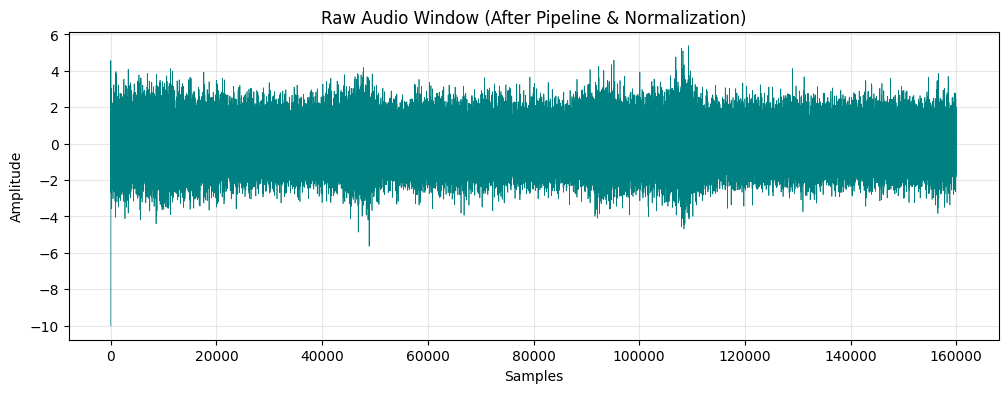

Max Amplitude: 5.38
Min Amplitude: -10.01
Check: Is the plot mostly a flat line? (Problem). Are there spikes? (Good).
------------------------------
--- Running Test 1: Single Pass ---
Success!
Windows in bag: 104
Feature Dim:    768
Logits shape:   torch.Size([1, 5])
Attention sum:  1.00 (Should be 1.0)
------------------------------
--- Running Test 2: Overfitting One Sample ---
Initial Loss:
  Iteration 0: Loss 0.6846
  Iteration 5: Loss 0.1003
  Iteration 10: Loss 0.0164
  Iteration 15: Loss 0.0047
If loss dropped significantly, the math is correct.
------------------------------
--- Running Test 5: GPU Memory Stress Test ---
GPU handled 15 windows (approx 80-90s of audio) successfully.
------------------------------
All sanity checks complete. Ready to train!


In [17]:
def run_all_sanity_checks():
    test_dataset_health(CSV_PATH)
    test_visualize_augmentation(full_dataset)
    test_single_pass(full_dataset, encoder, probe, device)
    test_overfit_small_batch(full_dataset, encoder, probe, device)
    test_gpu_memory(full_dataset, encoder, device)
    print("All sanity checks complete. Ready to train!")

#1. Hardware
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Paths
CSV_PATH = "bat_metadata.csv"
AUDIO_DIR = r"C:\Users\anast\Desktop\College\BA6\Bachelor Project\Source Code\cnn-call-classifier\BEATS Linear classifier\xenocanto-dataset"
NOISE_DIR = None

# 3. Initialize Encoder
print("Initializing NatureLM...")
encoder = load_model("esp_aves2_sl_beats_bio", device=device, return_features_only=True)
encoder.eval()

# 4. Initialize Dataset
print("Initializing Dataset...")
full_dataset = PipistrelleDataset(
    csv_file=CSV_PATH, 
    root_dir=AUDIO_DIR, 
    noise_folder=NOISE_DIR, 
    is_training=True
)

# 5. Initialize Probe
print("Initializing Probe...")
probe = BatAttentionProbe(encoder_dim=768, num_classes=5).to(device)

# --- NOW RUN YOUR TESTS ---
# run_all_sanity_checks()


run_all_sanity_checks()